# 02 · Panel EDA — the joined country table

Inspect `data/processed/panel.csv` before modelling: who's in, who's out, distributions, first look at MDD-W vs PUA, and whether survey source looks like a confounder.

In [1]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_rows", 200, "display.width", 160)
p = pd.read_csv("../data/processed/panel.csv")
log = json.load(open("../results/join_log.json"))
print(f"{log['n_panel']} countries in panel; {len(log['dropped'])} MDD-W countries dropped")
pd.DataFrame(log["dropped"])

66 countries in panel; 13 MDD-W countries dropped


,country,iso3,reason
0,Afghanistan,AFG,no CoAHD data
1,Georgia,GEO,no CoAHD data
2,Cambodia,KHM,no CoAHD within +/-2y of 2022
3,Libya,LBY,no CoAHD data
4,Oman,OMN,no CoAHD within +/-2y of 2017
5,Somalia,SOM,no CoAHD within +/-2y of 2023
6,Thailand,THA,no CoAHD within +/-2y of 2023
7,Tajikistan,TJK,no CoAHD within +/-2y of 2023
8,Timor-Leste,TLS,no CoAHD data
9,Ukraine,UKR,no CoAHD data


In [2]:
p.describe().round(2)

,mddw,mddw_year,pua,pua_year,cohd,pua_latest,pua_latest_year,gdp_pcap_ppp,gdp_year,n_interviews,design_effect,excluded_pct,n_eff_women,mddw_se
count,66.00,66.00,66.00,66.00,66.00,66.00,66.0,66.00,66.00,46.00,46.00,60.00,66.00,66.00
mean,59.36,2022.42,47.05,2022.42,4.12,45.01,2025.0,11585.38,2022.42,1056.93,1.63,2.27,2508.66,1.91
std,23.64,1.18,26.96,1.18,0.88,27.52,0.0,12611.65,1.18,368.33,0.30,5.16,3947.47,0.97
min,17.20,2018.00,1.10,2018.00,2.59,1.10,2025.0,1033.01,2018.00,1000.00,1.25,0.00,177.01,0.38
25%,39.51,2022.00,23.32,2022.00,3.55,18.42,2025.0,3475.26,2022.00,1000.00,1.43,0.00,269.07,0.92
50%,58.79,2023.00,49.60,2023.00,3.99,45.95,2025.0,7941.10,2023.00,1000.00,1.52,0.00,312.56,2.24
75%,79.33,2023.00,68.60,2023.00,4.52,67.58,2025.0,15880.18,2023.00,1002.00,1.78,1.25,2000.00,2.67
max,91.20,2024.00,92.10,2024.00,6.74,92.70,2025.0,85383.36,2024.00,3500.00,2.56,23.00,10000.00,3.46


In [3]:
p[["country","mddw","mddw_year","mddw_source_group","pua","pua_year","gdp_pcap_ppp","region","income"]].sort_values("pua")

,country,mddw,mddw_year,mddw_source_group,pua,pua_year,gdp_pcap_ppp,region,income
9,Switzerland,90.89,2023,GDQP,1.1,2023,85383.356450,Europe & Central Asia,High income
49,Malaysia,62.94,2023,GDQP,1.9,2023,32857.667660,East Asia & Pacific,Upper middle income
30,Jordan,76.40,2023,DHS,2.4,2023,10308.782199,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
31,Kazakhstan,88.02,2021,GDQP,6.3,2021,32945.851573,Europe & Central Asia,Upper middle income
60,Tunisia,90.82,2022,GDQP,7.6,2022,12712.223455,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income
8,Bolivia (Plurinational State of),87.14,2021,GDQP,8.9,2021,11202.440984,Latin America & Caribbean,Lower middle income
58,Serbia,87.81,2024,GDQP,9.4,2024,26900.741534,Europe & Central Asia,Upper middle income
64,Viet Nam,88.67,2021,GDQP,9.6,2021,12048.901994,East Asia & Pacific,Upper middle income
38,Morocco,75.63,2021,GDQP,12.5,2021,8623.265625,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income
7,Bosnia and Herzegovina,75.81,2024,GDQP,12.7,2024,20578.499545,Europe & Central Asia,Upper middle income


In [4]:
# Year alignment: does the CoAHD year equal the MDD-W survey year?
(p.pua_year - p.mddw_year).value_counts()

0    66
Name: count, dtype: int64

In [5]:
p.groupby("region").agg(n=("iso3","size"), mddw=("mddw","median"), pua=("pua","median")).sort_values("n", ascending=False)

,n,mddw,pua
region,,,
Sub-Saharan Africa,32,36.570,68.75
Europe & Central Asia,11,87.810,15.00
"Middle East, North Africa, Afghanistan & Pakistan",9,77.490,28.10
East Asia & Pacific,6,79.750,26.60
Latin America & Caribbean,6,77.150,38.85
South Asia,2,57.245,33.00


In [6]:
p.groupby("mddw_source_group").agg(n=("iso3","size"), mddw=("mddw","median"), pua=("pua","median"), gdp=("gdp_pcap_ppp","median")).round(1)

,n,mddw,pua,gdp
mddw_source_group,,,,
DHS,14,31.8,75.4,4006.4
GDQP,46,74.9,40.0,12214.6
Other,6,44.1,55.2,2713.9


## MDD-W vs % unable to afford a healthy diet — raw scatter

Pearson r = -0.807 | Spearman = -0.802


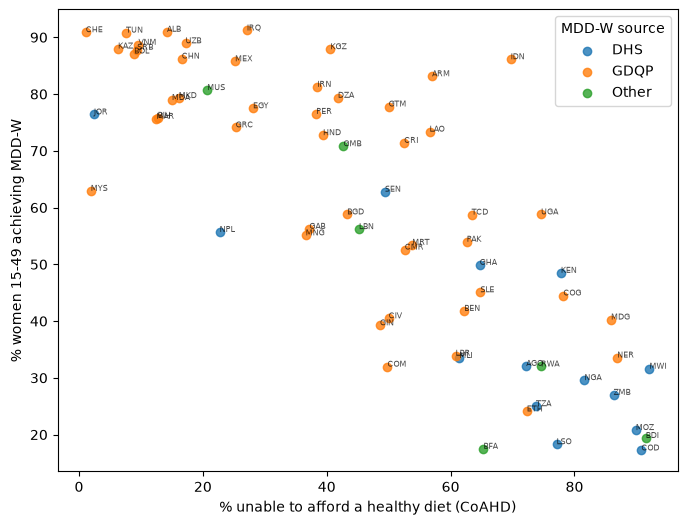

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
for g, sub in p.groupby("mddw_source_group"):
    ax.scatter(sub.pua, sub.mddw, label=g, alpha=.8)
for _, r in p.iterrows(): ax.annotate(r.iso3, (r.pua, r.mddw), fontsize=6, alpha=.7)
ax.set_xlabel("% unable to afford a healthy diet (CoAHD)"); ax.set_ylabel("% women 15-49 achieving MDD-W"); ax.legend(title="MDD-W source")
print("Pearson r =", round(np.corrcoef(p.pua, p.mddw)[0,1], 3), "| Spearman =", round(p[["pua","mddw"]].corr("spearman").iloc[0,1], 3))

Two questions to keep in mind for the model:
1. Is the relationship linear in PUA, or does it bend? (both variables are bounded 0–100)
2. Do DHS-sourced points sit systematically below the GDQP points at the same PUA? If yes, source is a confounder, not just noise.

r(mddw, log gdp) = 0.784 | r(pua, log gdp) = -0.78


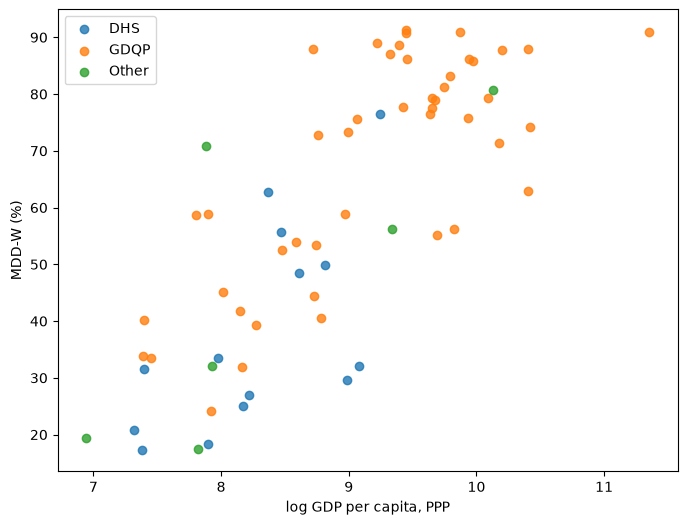

In [8]:
# Same plot against log GDP per capita — is affordability just income in disguise?
fig, ax = plt.subplots(figsize=(8,6))
for g, sub in p.groupby("mddw_source_group"): ax.scatter(np.log(sub.gdp_pcap_ppp), sub.mddw, label=g, alpha=.8)
ax.set_xlabel("log GDP per capita, PPP"); ax.set_ylabel("MDD-W (%)"); ax.legend()
print("r(mddw, log gdp) =", round(np.corrcoef(np.log(p.gdp_pcap_ppp), p.mddw)[0,1], 3),
      "| r(pua, log gdp) =", round(np.corrcoef(np.log(p.gdp_pcap_ppp), p.pua)[0,1], 3))

In [9]:
# Sensitivity input: matched-year PUA vs latest PUA — how much does the affordability picture move?
(p.pua_latest - p.pua).describe().round(2)

count    66.00
mean     -2.04
std       4.10
min     -18.50
25%      -3.47
50%      -1.10
75%       0.15
max      10.40
dtype: float64

In [10]:
# Countries with repeat MDD-W surveys — the within-country spread is a rough measurement-error scale
m = pd.read_csv("../data/processed/mddw_all_surveys.csv")
rep = m.groupby("iso3").filter(lambda g: len(g) > 1)
rep.groupby("iso3").agg(country=("country","first"), n=("year","size"), sources=("source_group", lambda s: "/".join(s)), min=("mddw","min"), max=("mddw","max")).assign(range=lambda d: d["max"]-d["min"]).sort_values("range", ascending=False)

,country,n,sources,min,max,range
iso3,,,,,,
UZB,Uzbekistan,2,Other/GDQP,40.40,88.94,48.54
COD,Democratic Republic of the Congo,2,GDQP/DHS,17.20,48.97,31.77
MOZ,Mozambique,2,GDQP/DHS,20.80,51.58,30.78
NGA,Nigeria,3,DHS/GDQP/DHS,29.60,55.60,26.00
MLI,Mali,2,GDQP/DHS,33.50,58.03,24.53
SLE,Sierra Leone,3,Other/DHS/GDQP,45.08,68.40,23.32
JOR,Jordan,3,Other/GDQP/DHS,54.00,76.40,22.40
MWI,Malawi,2,GDQP/DHS,31.60,53.05,21.45
KEN,Kenya,2,GDQP/DHS,48.50,69.26,20.76
